In [ ]:

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from gensim.models import Word2Vec
from sklearn.utils import resample
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.svm import SVR
import seaborn as sns
import pandas as pd
import numpy as np
import re

## 1. Text Vectorization

- SentenceTransformer (Semantic Embeddings):

In [14]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')


In [ ]:
labeled_df = pd.read_csv("labeled-data.csv")
unlabeled_df = pd.read_csv("unlabeled-data.csv")
labeled_embeddings = model.encode(labeled_df["review_text"].tolist(), show_progress_bar=True)
unlabeled_embeddings = model.encode(unlabeled_df["review_text"].tolist(), show_progress_bar=True)


Batches: 100%|██████████| 157/157 [00:10<00:00, 14.46it/s]


- Word2Vec (Distributed Word Representations):

In [15]:
labeled_df = pd.read_csv("labeled-data.csv")
unlabeled_df = pd.read_csv("unlabeled-data.csv")
all_texts = labeled_df["review_text"].tolist() + unlabeled_df["review_text"].tolist()

def preprocess(text):
    text = re.sub(r"[^a-zA-Z]", " ", text)
    return text.lower().split()

tokenized_texts = [preprocess(t) for t in all_texts]



In [16]:

w2v_model = Word2Vec(
    sentences=tokenized_texts,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

def sentence_vector(tokens, model):
    vectors = [model.wv[w] for w in tokens if w in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

labeled_embeddings_w2v = [sentence_vector(preprocess(t), w2v_model)
                           for t in labeled_df["review_text"].tolist()]

unlabeled_embeddings_w2v = [sentence_vector(preprocess(t), w2v_model)
                             for t in unlabeled_df["review_text"].tolist()]


- Dimensionality Reduction and Visualization:

In [18]:
X = np.array(labeled_embeddings)
y = labeled_df["review_score"].values

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)


In [19]:
X_w2v = np.array(labeled_embeddings_w2v)
X_reduced_w2v = PCA(n_components=2).fit_transform(X_w2v)


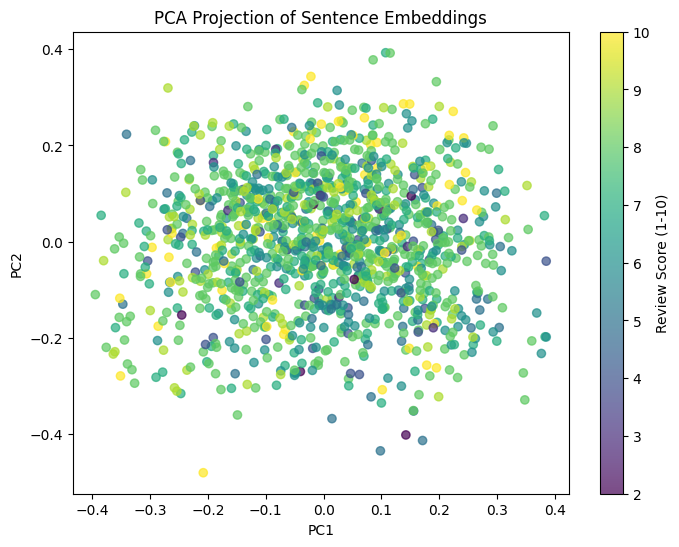

In [20]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_reduced[:,0], X_reduced[:,1],
                      c=y, cmap="viridis", alpha=0.7)
plt.colorbar(scatter, label="Review Score (1-10)")
plt.title("PCA Projection of Sentence Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


We don't observe any clear pattern or clustering in the scatter plot. It may be for the following reasons:

1. __Semantic Complexity of Texts__<br><br>
Review texts are usually short and can be expressed in very diverse ways.<br>
For example, two reviews might use very similar sentences, yet one gives a score of 10 while the other gives a 7.<br>
Therefore, embeddings do not necessarily capture the subtle differences between close scores (e.g., 7 vs. 8).<br>

2. __General-Purpose Embedding Model__<br><br>
SentenceTransformer models (e.g., all-MiniLM-L6-v2) are trained on general-purpose data, not specifically on video game reviews.<br>
As a result, they may fail to reflect fine-grained distinctions between positive and negative reviews or the degree of satisfaction.<br>

3. __Nature of Labeled Data__<br><br>
The labeled dataset is small → not enough to show strong clustering.<br>
If we only have a few hundred samples, PCA may not be able to uncover meaningful structures.<br>

4. __Noise and Subjectivity in Scoring__<br><br>
Human-assigned scores are highly subjective.<br>
Two users might write very similar reviews, but one assigns a 6 and the other a 9.<br>
This causes the colors (scores) to mix and overlap in the embedding space.<br>

5. __Limitations of PCA__<br><br>
PCA only preserves linear relationships.<br>
If the true structure of the data is nonlinear (which is often the case), algorithms such as t-SNE or UMAP are better suited to reveal patterns<br>
Therefore, the absence of clear clustering does not necessarily mean the embeddings are useless.<br>



## 2. Supervised Learning Baselines

- Classification Paradigm:

In [36]:

X = labeled_embeddings
y = labeled_df["review_score"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=None
)

print("Train:", len(y_train), "Val:", len(y_val), "Test:", len(y_test))


Train: 1000 Val: 125 Test: 125


In [37]:
clf = LogisticRegression(max_iter=2000, multi_class="multinomial")
clf.fit(X_train, y_train)


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=2000, multi_class='multinomial')

In [38]:

rf_clf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_clf.fit(X_train, y_train)


RandomForestClassifier(n_estimators=200, random_state=42)

In [39]:
svc_clf = SVC(probability=True)
svc_clf.fit(X_train, y_train)


SVC(probability=True)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.36
Precision: 0.16772171831695643
Recall: 0.1385052208471221
F1-score: 0.11743093824048675


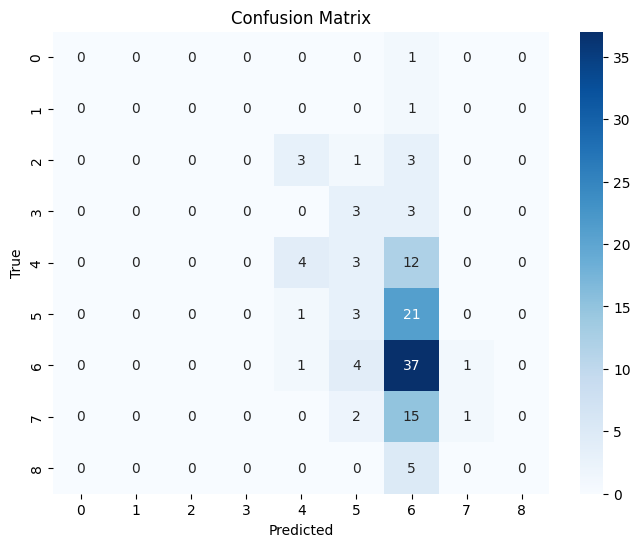

In [ ]:
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro")

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


- Regression Paradigm:

In [45]:


X = np.array(labeled_embeddings)
#X = np.array(labeled_embeddings_w2v)
y = labeled_df["review_score"].to_numpy()

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

models = {
    "LinearRegression": LinearRegression(),
    "SVR_RBF": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("svr", SVR(kernel="rbf", C=10.0, epsilon=0.2))
    ]),
    "RandomForest": RandomForestRegressor(
        n_estimators=300, max_depth=None, random_state=42, n_jobs=-1
    )
}


- Implementation:

In [46]:
def evaluate_regression(name, model, X_tr, y_tr, X_va, y_va, X_te, y_te, clip_to_range=True):
    model.fit(X_tr, y_tr)
    
    def eval_split(split_name, Xs, ys):
        y_pred = model.predict(Xs)
        if clip_to_range:
            y_pred = np.clip(y_pred, 1.0, 10.0)

        mae  = mean_absolute_error(ys, y_pred)
        mse  = mean_squared_error(ys, y_pred)
        rmse = np.sqrt(mse)
        r2   = r2_score(ys, y_pred)

        y_pred_round = np.rint(y_pred).astype(int)
        y_pred_round = np.clip(y_pred_round, 1, 10)
        round_acc = (y_pred_round == ys).mean()

        return mae, mse, rmse, r2, round_acc


    tr_mae, tr_mse, tr_rmse, tr_r2, tr_acc = eval_split("Train", X_tr, y_tr)
    va_mae, va_mse, va_rmse, va_r2, va_acc = eval_split("Val", X_va, y_va)

    X_trval = np.vstack([X_tr, X_va])
    y_trval = np.concatenate([y_tr, y_va])
    model.fit(X_trval, y_trval)
    te_mae, te_mse, te_rmse, te_r2, te_acc = eval_split("Test", X_te, y_te)

    print(f"\n=== {name} ===")
    print(f"Train -> MAE: {tr_mae:.3f} | RMSE: {tr_rmse:.3f} | R2: {tr_r2:.3f} | Rounded-Acc: {tr_acc:.3f}")
    print(f"Val   -> MAE: {va_mae:.3f} | RMSE: {va_rmse:.3f} | R2: {va_r2:.3f} | Rounded-Acc: {va_acc:.3f}")
    print(f"Test  -> MAE: {te_mae:.3f} | RMSE: {te_rmse:.3f} | R2: {te_r2:.3f} | Rounded-Acc: {te_acc:.3f}")

for name, model in models.items():
    evaluate_regression(name, model, X_train, y_train, X_val, y_val, X_test, y_test, clip_to_range=True)



=== LinearRegression ===
Train -> MAE: 0.744 | RMSE: 0.956 | R2: 0.589 | Rounded-Acc: 0.414
Val   -> MAE: 1.097 | RMSE: 1.332 | R2: 0.251 | Rounded-Acc: 0.240
Test  -> MAE: 1.225 | RMSE: 1.612 | R2: 0.004 | Rounded-Acc: 0.280

=== SVR_RBF ===
Train -> MAE: 0.185 | RMSE: 0.190 | R2: 0.984 | Rounded-Acc: 1.000
Val   -> MAE: 0.905 | RMSE: 1.143 | R2: 0.448 | Rounded-Acc: 0.352
Test  -> MAE: 0.988 | RMSE: 1.293 | R2: 0.360 | Rounded-Acc: 0.368

=== RandomForest ===
Train -> MAE: 0.389 | RMSE: 0.507 | R2: 0.884 | Rounded-Acc: 0.737
Val   -> MAE: 1.038 | RMSE: 1.340 | R2: 0.241 | Rounded-Acc: 0.352
Test  -> MAE: 1.140 | RMSE: 1.486 | R2: 0.154 | Rounded-Acc: 0.304


## 3. Semi-Supervised Learning (SSL) Strategies

### 3.1.Pseudo-Labeling

- Key Concepts:

In [47]:
X_labeled   = np.array(labeled_embeddings)              # labeled_embeddings_w2v
y_labeled   = labeled_df["review_score"].to_numpy()
X_unlabeled = np.array(unlabeled_embeddings)

In [ ]:
def build_svr_pipeline(C=10.0, epsilon=0.2, gamma="scale"):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(kernel="rbf", C=C, epsilon=epsilon, gamma=gamma))
    ])
def train_ensemble_svr(X, y, n_models=7, random_state=42):
    rng = np.random.RandomState(random_state)
    models = []
    n = X.shape[0]
    for m in range(n_models):
        idx = rng.randint(0, n, size=n)
        X_b, y_b = X[idx], y[idx]
        model = build_svr_pipeline()
        model.fit(X_b, y_b)
        models.append(model)
    return models

def predict_with_uncertainty(models, X):
    if X is None or len(X) == 0:
        return np.array([]), np.array([])
    preds = np.column_stack([mdl.predict(X) for mdl in models])
    mean_pred = preds.mean(axis=1)
    std_pred  = preds.std(axis=1)
    return mean_pred, std_pred

In [62]:
def select_high_confidence(mean_pred, std_pred, 
                           sigma_thresh=0.60, 
                           delta_to_int_thresh=None, 
                           top_k=None):
    if mean_pred.size == 0:
        return np.array([], dtype=int)
    mask = std_pred <= sigma_thresh
    candidates = np.where(mask)[0]

    if delta_to_int_thresh is not None and candidates.size > 0:
        nearest_int = np.rint(mean_pred[candidates])
        delta = np.abs(mean_pred[candidates] - nearest_int)
        candidates = candidates[delta <= delta_to_int_thresh]

    if top_k is not None and candidates.size > top_k:
        order = np.argsort(std_pred[candidates])
        candidates = candidates[order[:top_k]]

    return candidates

def eval_regression(y_true, y_pred, clip_to_1_10=True):
    if clip_to_1_10:
        y_pred = np.clip(y_pred, 1.0, 10.0)
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)  
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    y_round = np.rint(y_pred).astype(int)
    y_round = np.clip(y_round, 1, 10)
    acc = (y_round == y_true).mean()
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "RoundedAcc": acc}


def make_pseudo_labels(mean_pred):
    return np.clip(mean_pred, 1.0, 10.0)


def print_report(title, metrics_dict):
    print(f"\n[{title}]  MAE: {metrics_dict['MAE']:.3f} | RMSE: {metrics_dict['RMSE']:.3f} | "
          f"R2: {metrics_dict['R2']:.3f} | Rounded-Acc: {metrics_dict['RoundedAcc']:.3f}")


- Implementation:

In [65]:
X_tr_base = np.vstack([X_train, X_val])
y_tr_base = np.concatenate([y_train, y_val])

ROUNDS            = 5
N_MODELS_ENSEMBLE = 7
SIGMA_THRESH      = 0.60
DELTA_INT_THRESH  = None
TOP_K_PER_ROUND   = None

history = []

X_tr_dyn = X_tr_base.copy()
y_tr_dyn = y_tr_base.copy()

remaining_idx = np.arange(X_unlabeled.shape[0])

In [ ]:
history = []
X_tr_dyn = np.vstack([X_train, X_val])
y_tr_dyn = np.concatenate([y_train, y_val])
remaining_idx = np.arange(X_unlabeled.shape[0])

print("Initial unlabeled size:", remaining_idx.size)

for r in range(1, ROUNDS + 1):
    print(f"\n=== Pseudo-Labeling Round {r}/{ROUNDS} ===")

    ens = train_ensemble_svr(X_tr_dyn, y_tr_dyn, n_models=N_MODELS_ENSEMBLE, random_state=42 + r)

    mean_test, std_test = predict_with_uncertainty(ens, X_test)
    metrics_before = eval_regression(y_test, mean_test, clip_to_1_10=True)
    print_report("Before adding new pseudo-labels (Test)", metrics_before)

    if remaining_idx.size == 0:
        print("No unlabeled samples remaining. Stopping.")
        history.append({"round": r, "added": 0, **metrics_before})
        break

    X_unl_rem = X_unlabeled[remaining_idx]

    if X_unl_rem.shape[0] == 0:
        print("Unlabeled pool is empty (shape=(0, d)). Stopping.")
        history.append({"round": r, "added": 0, **metrics_before})
        break

    mean_u, std_u = predict_with_uncertainty(ens, X_unl_rem)

    if mean_u.size == 0:
        print("Empty predictions for unlabeled pool. Stopping.")
        history.append({"round": r, "added": 0, **metrics_before})
        break

    chosen_local = select_high_confidence(
        mean_pred=mean_u,
        std_pred=std_u,
        sigma_thresh=SIGMA_THRESH,
        delta_to_int_thresh=DELTA_INT_THRESH,
        top_k=TOP_K_PER_ROUND
    )
    n_chosen = int(len(chosen_local))
    print(f"Selected high-confidence unlabeled samples this round: {n_chosen}")
    print("Remaining unlabeled BEFORE removal:", remaining_idx.size)

    if n_chosen == 0:
        print("No confident samples found. Stopping early.")
        history.append({"round": r, "added": 0, **metrics_before})
        break

    chosen_idx_global = remaining_idx[chosen_local]
    pseudo_y = make_pseudo_labels(mean_u[chosen_local])

    X_tr_dyn = np.vstack([X_tr_dyn, X_unlabeled[chosen_idx_global]])
    y_tr_dyn = np.concatenate([y_tr_dyn, pseudo_y])

    keep_mask = np.ones_like(remaining_idx, dtype=bool)
    keep_mask[chosen_local] = False
    remaining_idx = remaining_idx[keep_mask]
    print("Remaining unlabeled AFTER removal:", remaining_idx.size)

    ens_after = train_ensemble_svr(X_tr_dyn, y_tr_dyn, n_models=N_MODELS_ENSEMBLE, random_state=100 + r)
    mean_test_after, std_test_after = predict_with_uncertainty(ens_after, X_test)
    metrics_after = eval_regression(y_test, mean_test_after, clip_to_1_10=True)
    print_report("After adding pseudo-labels (Test)", metrics_after)

    history.append({"round": r, "added": n_chosen, **metrics_after})

history_df = pd.DataFrame(history)
display(history_df)


Initial unlabeled size: 5000

=== Pseudo-Labeling Round 1/5 ===

[Before adding new pseudo-labels (Test)]  MAE: 0.994 | RMSE: 1.320 | R2: 0.332 | Rounded-Acc: 0.368
Selected high-confidence unlabeled samples this round: 4979
Remaining unlabeled BEFORE removal: 5000
Remaining unlabeled AFTER removal: 21

[After adding pseudo-labels (Test)]  MAE: 0.993 | RMSE: 1.317 | R2: 0.335 | Rounded-Acc: 0.376

=== Pseudo-Labeling Round 2/5 ===

[Before adding new pseudo-labels (Test)]  MAE: 0.992 | RMSE: 1.314 | R2: 0.338 | Rounded-Acc: 0.400
Selected high-confidence unlabeled samples this round: 19
Remaining unlabeled BEFORE removal: 21
Remaining unlabeled AFTER removal: 2

[After adding pseudo-labels (Test)]  MAE: 0.998 | RMSE: 1.326 | R2: 0.327 | Rounded-Acc: 0.384

=== Pseudo-Labeling Round 3/5 ===

[Before adding new pseudo-labels (Test)]  MAE: 1.003 | RMSE: 1.320 | R2: 0.333 | Rounded-Acc: 0.384
Selected high-confidence unlabeled samples this round: 1
Remaining unlabeled BEFORE removal: 2
Rem

,round,added,MAE,RMSE,R2,RoundedAcc
0,1,4979,0.993052,1.317417,0.335101,0.376
1,2,19,0.998170,1.325731,0.326683,0.384
2,3,1,0.996633,1.309070,0.343500,0.376
3,4,1,0.985298,1.309466,0.343103,0.384
4,5,0,0.999470,1.325236,0.327185,0.376


### 3.2. Active Learning:

- Common Query Strategies:

In [68]:

def regression_uncertainty_std(std_pred: np.ndarray) -> np.ndarray:
    return std_pred

def select_topk_uncertain_regression(std_pred: np.ndarray, k: int = 50) -> np.ndarray:

    k = min(k, len(std_pred))
    order = np.argsort(-std_pred)
    return order[:k]

def least_confidence_scores(proba: np.ndarray) -> np.ndarray:
    max_p = proba.max(axis=1)
    return 1.0 - max_p 

def margin_sampling_scores(proba: np.ndarray) -> np.ndarray:
    sp = np.sort(proba, axis=1)[:, ::-1]
    margin = sp[:, 0] - sp[:, 1]
    return 1.0 - margin

def entropy_scores(proba: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    p = np.clip(proba, eps, 1.0)
    return -(p * np.log(p)).sum(axis=1)

def select_topk_uncertain_classification(scores: np.ndarray, k: int = 50) -> np.ndarray:
    k = min(k, len(scores))
    order = np.argsort(-scores)
    return order[:k]


- Implementation:

Initial unlabeled size: 5000

=== Active Learning Round 1/6 ===
Test -> MAE: 1.016 | RMSE: 1.330 | R2: 0.322 | Rounded-Acc: 0.376
Querying top-50 most-uncertain samples for HUMAN labels...


,global_index,review_text
0,3559,"Its gameplay mechanics are at best, boring, an..."
1,73,"Many of the game's elements are dated, while o..."
2,3500,Fuzion Frenzy 2 is like a decent-tasting smoot...
3,4183,Rainbow Skies is an epic adventure with a much...
4,3210,Immortal: Unchained isn’t inherently an awful ...
5,4250,"You can ""create the ultimate coaster -- and ri..."
6,2452,Hydrophobia Prophecy is a challenging and orig...
7,4517,Old Gods Rising is an unfortunate mess. While ...
8,3597,Reality Fighters is a well-polished offering w...
9,2968,Rainbow Skies is an indie old school SRPG hidi...


Saved al_round_1_to_label.csv.  Fill a score (1..10) for each row, then bring it back as a list in MANUAL_LABELS_HERE.
Remaining unlabeled AFTER querying: 4950

=== Active Learning Round 2/6 ===
Test -> MAE: 0.983 | RMSE: 1.294 | R2: 0.359 | Rounded-Acc: 0.384
Querying top-50 most-uncertain samples for HUMAN labels...


,global_index,review_text
0,881,Quarrel is a charming and challenging little w...
1,2033,Immortal Unchained could have been a great att...
2,3615,Sports Bar VR needs a couple of important patc...
3,3917,"The game’s world is just gorgeous, lovingly pu..."
4,501,SportsBarVR is a solid collection of multiplay...
5,43,Quarrel! is one of those games that comes from...
6,2363,Those who enjoyed Grasshopper’s previous work ...
7,1456,Underneath the intriguing concept and gorgeous...
8,405,"Blade Kitten is, overall, a disappointing expe..."
9,3084,Need for Speed Unbound is the franchise’s best...


Saved al_round_2_to_label.csv.  Fill a score (1..10) for each row, then bring it back as a list in MANUAL_LABELS_HERE.
Remaining unlabeled AFTER querying: 4900

=== Active Learning Round 3/6 ===
Test -> MAE: 1.004 | RMSE: 1.314 | R2: 0.339 | Rounded-Acc: 0.368
Querying top-50 most-uncertain samples for HUMAN labels...


...

,global_index,review_text
0,173,Rock Band 3 is simply perfect. It's the final ...
1,516,"Overall, Rock Band 3 does a great job of refin..."
2,4635,Breathtaking in ambition and crafted with the ...
3,2132,There's a reason why New Super Mario Bros. sol...
4,1808,"Rock Band 3 have an amazing track list, an exc..."
5,527,"With New Super Mario Bros. Wii, Mario goes bac..."
6,4558,"In conclusion, we can only invite you to play ..."
7,4302,Rock Band 3 is the best music game option arou...
8,846,"The unavoidable reality is that, for all Rock ..."
9,1292,"New instruments, new ways of understading the ..."


Saved al_round_5_to_label.csv.  Fill a score (1..10) for each row, then bring it back as a list in MANUAL_LABELS_HERE.
Remaining unlabeled AFTER querying: 4750

=== Active Learning Round 6/6 ===
Test -> MAE: 0.998 | RMSE: 1.319 | R2: 0.333 | Rounded-Acc: 0.376
Querying top-50 most-uncertain samples for HUMAN labels...


,global_index,review_text
0,4930,They've brought in most of the standard instru...
1,4232,It doesn’t matter if your first gaming system ...
2,373,If your bank account can withstand the investm...
3,3448,The latest game featuring Sonic is a mixed exp...
4,4011,Little Witch Academia: Chamber of Time represe...
5,1997,"Forgotten Fields, at first glance, is intrigui..."
6,22,Even if 2D Super Mario Bros can't be the avant...
7,4248,Batman Arkham Knight is the best entry in the ...
8,3967,With not much of value in the narrative or the...
9,2808,Super Princess Peach is Super Mario for dummie...


Saved al_round_6_to_label.csv.  Fill a score (1..10) for each row, then bring it back as a list in MANUAL_LABELS_HERE.
Remaining unlabeled AFTER querying: 4700

=== Active Learning Summary ===


,round,added,labeled_size,MAE,RMSE,R2,RoundedAcc
0,1,50,1175,1.016075,1.330429,0.321902,0.376
1,2,50,1225,0.983269,1.293863,0.358664,0.384
2,3,50,1275,1.004351,1.313649,0.338900,0.368
3,4,50,1325,0.993641,1.310329,0.342237,0.360
4,5,50,1375,0.995888,1.320239,0.332250,0.368
5,6,50,1425,0.998395,1.319346,0.333153,0.376


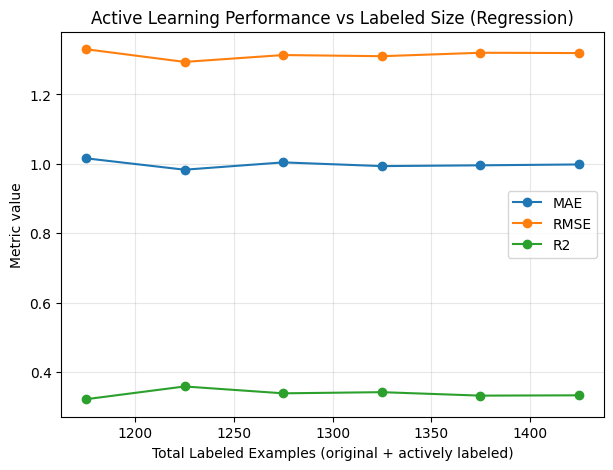

In [ ]:

def eval_regression(y_true, y_pred, clip_to_1_10=True):
    if clip_to_1_10:
        y_pred = np.clip(y_pred, 1.0, 10.0)
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    y_round = np.rint(y_pred).astype(int)
    y_round = np.clip(y_round, 1, 10)
    acc = (y_round == y_true).mean()
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "RoundedAcc": acc}

def build_svr_pipeline(C=10.0, epsilon=0.2, gamma="scale"):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(kernel="rbf", C=C, epsilon=epsilon, gamma=gamma))
    ])

def train_ensemble_svr(X, y, n_models=7, random_state=42):
    rng = np.random.RandomState(random_state)
    models = []
    n = X.shape[0]
    for m in range(n_models):
        idx = rng.randint(0, n, size=n)  # bootstrap
        X_b, y_b = X[idx], y[idx]
        mdl = build_svr_pipeline()
        mdl.fit(X_b, y_b)
        models.append(mdl)
    return models

def predict_with_uncertainty(models, X):
    if X is None or len(X) == 0:
        return np.array([]), np.array([])
    preds = np.column_stack([mdl.predict(X) for mdl in models])
    return preds.mean(axis=1), preds.std(axis=1)

AL_ROUNDS          = 6
AL_TOP_K           = 50
USE_TRAIN_PLUS_VAL = True
RANDOM_SEED        = 2025

if USE_TRAIN_PLUS_VAL:
    X_train_al = np.vstack([X_train, X_val])
    y_train_al = np.concatenate([y_train, y_val])
else:
    X_train_al = X_train.copy()
    y_train_al = y_train.copy()

X_unl_pool = np.array(unlabeled_embeddings)
remaining_idx_al = np.arange(X_unl_pool.shape[0])

al_hist = []

print("Initial unlabeled size:", remaining_idx_al.size)

for r in range(1, AL_ROUNDS + 1):
    print(f"\n=== Active Learning Round {r}/{AL_ROUNDS} ===")

    ens_al = train_ensemble_svr(X_train_al, y_train_al, n_models=7, random_state=RANDOM_SEED + r)

    mean_te, std_te = predict_with_uncertainty(ens_al, X_test)
    metrics_te = eval_regression(y_test, mean_te, clip_to_1_10=True)
    print(f"Test -> MAE: {metrics_te['MAE']:.3f} | RMSE: {metrics_te['RMSE']:.3f} | "
          f"R2: {metrics_te['R2']:.3f} | Rounded-Acc: {metrics_te['RoundedAcc']:.3f}")

    if remaining_idx_al.size == 0:
        print("No unlabeled samples remaining. Stopping.")
        al_hist.append({"round": r, "added": 0, "labeled_size": len(y_train_al), **metrics_te})
        break

    X_unl_rem = X_unl_pool[remaining_idx_al]
    if X_unl_rem.shape[0] == 0:
        print("Unlabeled pool empty. Stopping.")
        al_hist.append({"round": r, "added": 0, "labeled_size": len(y_train_al), **metrics_te})
        break

    mean_u, std_u = predict_with_uncertainty(ens_al, X_unl_rem)
    if mean_u.size == 0:
        print("Empty unlabeled predictions. Stopping.")
        al_hist.append({"round": r, "added": 0, "labeled_size": len(y_train_al), **metrics_te})
        break

    idx_local = select_topk_uncertain_regression(std_u, k=AL_TOP_K)
    n_query = int(len(idx_local))
    print(f"Querying top-{n_query} most-uncertain samples for HUMAN labels...")

    if n_query == 0:
        print("No uncertain samples to query. Stopping.")
        al_hist.append({"round": r, "added": 0, "labeled_size": len(y_train_al), **metrics_te})
        break

    sel_global = remaining_idx_al[idx_local]
    queried_texts = unlabeled_df.loc[sel_global, "review_text"].tolist()

    al_batch_df = pd.DataFrame({
        "global_index": sel_global,
        "review_text": queried_texts
    })
    display(al_batch_df.head(10))

    csv_path = f"al_round_{r}_to_label.csv"
    al_batch_df.to_csv(csv_path, index=False)
    print(f"Saved {csv_path}.  Fill a score (1..10) for each row, then bring it back as a list in MANUAL_LABELS_HERE.")


    MANUAL_LABELS_HERE = [
        3, 4, 6, 9, 4, 5, 6, 3, 6, 7,
        4, 7, 5, 2, 7, 8, 8, 10, 8, 8,
        3, 5, 8, 4, 8, 9, 8, 7, 7, 6,
        7, 7, 9, 8, 6, 5, 7, 8, 6, 8,
        9, 8, 8, 7, 7, 8, 9, 7, 7, 8
        ]


    if MANUAL_LABELS_HERE is None:
        raise ValueError(
            f"Active Learning requires HUMAN labels. Please set MANUAL_LABELS_HERE to a list of length {n_query} "
            "with integer scores in [1..10] based on reading the printed texts / CSV."
        )

    human_labels = np.asarray(MANUAL_LABELS_HERE, dtype=float)
    if human_labels.shape[0] != n_query:
        raise ValueError(f"Provided {human_labels.shape[0]} labels, but need exactly {n_query}.")
    human_labels = np.clip(human_labels, 1.0, 10.0)

    X_train_al = np.vstack([X_train_al, X_unl_pool[sel_global]])
    y_train_al = np.concatenate([y_train_al, human_labels])

    keep_mask = np.ones_like(remaining_idx_al, dtype=bool)
    keep_mask[idx_local] = False
    remaining_idx_al = remaining_idx_al[keep_mask]
    print("Remaining unlabeled AFTER querying:", remaining_idx_al.size)

    al_hist.append({"round": r, "added": n_query, "labeled_size": len(y_train_al), **metrics_te})

al_df = pd.DataFrame(al_hist)
print("\n=== Active Learning Summary ===")
display(al_df)

if not al_df.empty:
    plt.figure(figsize=(7,5))
    plt.plot(al_df["labeled_size"], al_df["MAE"], marker='o', label="MAE")
    plt.plot(al_df["labeled_size"], al_df["RMSE"], marker='o', label="RMSE")
    plt.plot(al_df["labeled_size"], al_df["R2"], marker='o', label="R2")
    plt.xlabel("Total Labeled Examples (original + actively labeled)")
    plt.ylabel("Metric value")
    plt.title("Active Learning Performance vs Labeled Size (Regression)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


## 4. Comparative Performance Analysis

- Summary of Metrics

In [71]:

baseline_metrics = {
    "Model": "Baseline (SVR)",
    "MAE": 0.988,
    "RMSE": 1.293,
    "R2": 0.360,
    "RoundedAcc": 0.368
}


summary_table = pd.DataFrame([baseline_metrics])
summary_table = pd.concat([
    summary_table,
    history_df.assign(Model=lambda df: "Pseudo-Round " + df["round"].astype(str)),
    al_df.assign(Model=lambda df: "Active-Round " + df["round"].astype(str))
], ignore_index=True)

summary_table = summary_table[["Model","MAE","RMSE","R2","RoundedAcc"]]
display(summary_table)


,Model,MAE,RMSE,R2,RoundedAcc
0,Baseline (SVR),0.988000,1.293000,0.360000,0.368
1,Pseudo-Round 1,0.993052,1.317417,0.335101,0.376
2,Pseudo-Round 2,0.998170,1.325731,0.326683,0.384
3,Pseudo-Round 3,0.996633,1.309070,0.343500,0.376
4,Pseudo-Round 4,0.985298,1.309466,0.343103,0.384
5,Pseudo-Round 5,0.999470,1.325236,0.327185,0.376
6,Active-Round 1,1.016075,1.330429,0.321902,0.376
7,Active-Round 2,0.983269,1.293863,0.358664,0.384
8,Active-Round 3,1.004351,1.313649,0.338900,0.368
9,Active-Round 4,0.993641,1.310329,0.342237,0.360


- ROC and AUC Curves

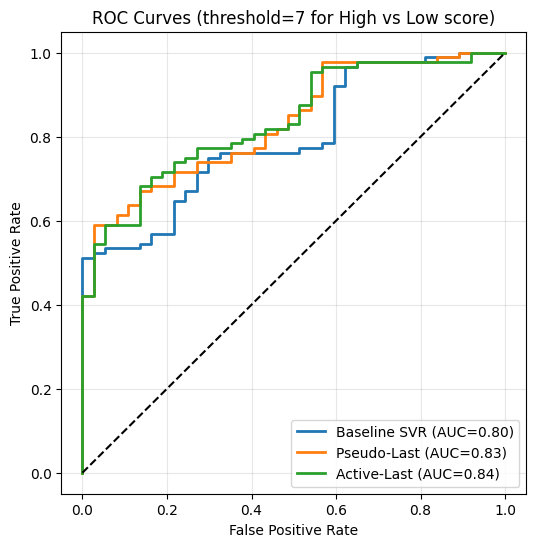

In [ ]:
def plot_roc(models_dict, X_test, y_test, threshold=7):
    plt.figure(figsize=(6,6))
    for name, model in models_dict.items():
        if isinstance(model, list):
            mean_pred, _ = predict_with_uncertainty(model, X_test)
        else:
            mean_pred = model.predict(X_test)

        y_true_bin = (y_test >= threshold).astype(int)
        y_score = mean_pred 
        fpr, tpr, _ = roc_curve(y_true_bin, y_score)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={roc_auc:.2f})")

    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves (threshold=7 for High vs Low score)")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

models_for_roc = {
    "Baseline SVR": train_ensemble_svr(X_train, y_train, n_models=7),
    "Pseudo-Last": train_ensemble_svr(X_tr_dyn, y_tr_dyn, n_models=7),
    "Active-Last": train_ensemble_svr(X_train_al, y_train_al, n_models=7)
}
plot_roc(models_for_roc, X_test, y_test)


- Learning Curves

In [ ]:
if "added" in history_df.columns:
    initial_size = len(y_train) + len(y_val)
    history_df = history_df.copy()
    history_df["labeled_size"] = initial_size + history_df["added"].cumsum()
else:
    initial_size = len(y_train) + len(y_val)
    step = 500
    history_df = history_df.copy()
    history_df["labeled_size"] = initial_size + history_df["round"] * step

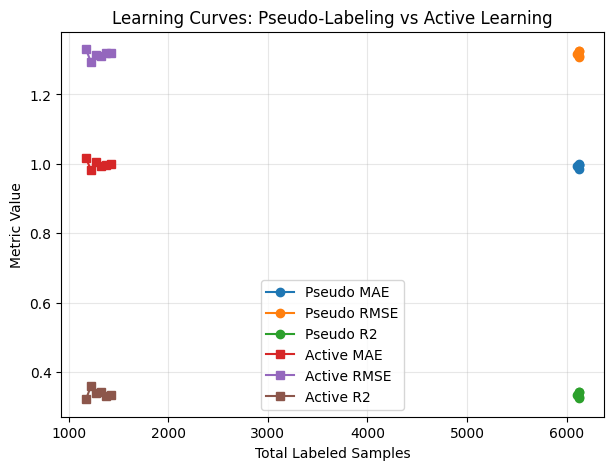

In [77]:

plt.figure(figsize=(7,5))

plt.plot(history_df["labeled_size"], history_df["MAE"], marker='o', label="Pseudo MAE")
plt.plot(history_df["labeled_size"], history_df["RMSE"], marker='o', label="Pseudo RMSE")
plt.plot(history_df["labeled_size"], history_df["R2"], marker='o', label="Pseudo R2")

plt.plot(al_df["labeled_size"], al_df["MAE"], marker='s', label="Active MAE")
plt.plot(al_df["labeled_size"], al_df["RMSE"], marker='s', label="Active RMSE")
plt.plot(al_df["labeled_size"], al_df["R2"], marker='s', label="Active R2")

plt.xlabel("Total Labeled Samples")
plt.ylabel("Metric Value")
plt.title("Learning Curves: Pseudo-Labeling vs Active Learning")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


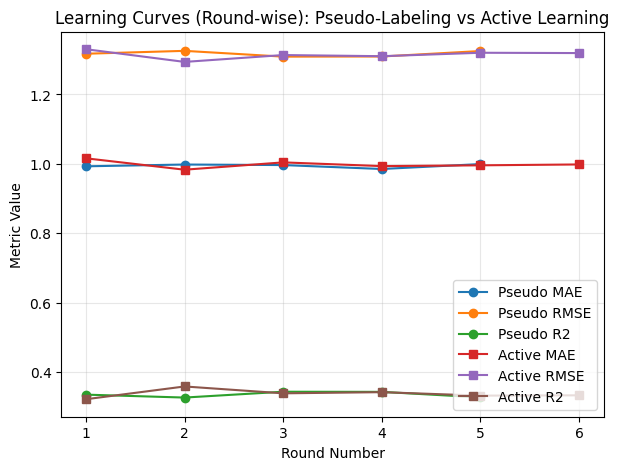

In [78]:
plt.figure(figsize=(7,5))

# Pseudo-labeling
plt.plot(history_df["round"], history_df["MAE"], marker='o', label="Pseudo MAE")
plt.plot(history_df["round"], history_df["RMSE"], marker='o', label="Pseudo RMSE")
plt.plot(history_df["round"], history_df["R2"], marker='o', label="Pseudo R2")

# Active learning
plt.plot(al_df["round"], al_df["MAE"], marker='s', label="Active MAE")
plt.plot(al_df["round"], al_df["RMSE"], marker='s', label="Active RMSE")
plt.plot(al_df["round"], al_df["R2"], marker='s', label="Active R2")

plt.xlabel("Round Number")
plt.ylabel("Metric Value")
plt.title("Learning Curves (Round-wise): Pseudo-Labeling vs Active Learning")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


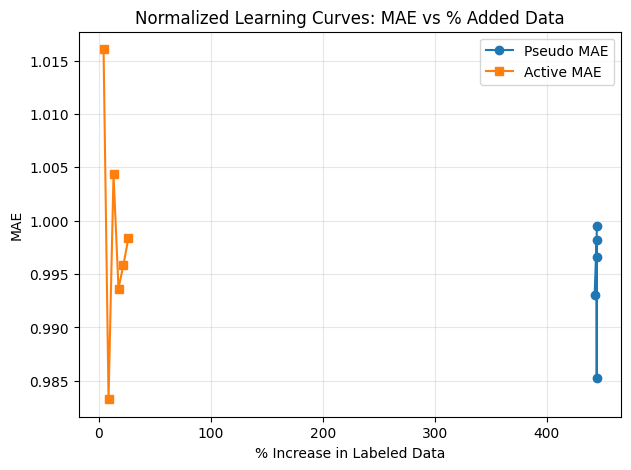

In [79]:
initial_size = len(y_train) + len(y_val)

# pseudo
if "added" in history_df.columns:
    history_df["perc_increase"] = 100 * history_df["added"].cumsum() / initial_size
else:
    history_df["perc_increase"] = history_df["round"] * (100/len(history_df))

# active
al_df["perc_increase"] = 100 * (al_df["labeled_size"] - initial_size) / initial_size

plt.figure(figsize=(7,5))
plt.plot(history_df["perc_increase"], history_df["MAE"], marker='o', label="Pseudo MAE")
plt.plot(al_df["perc_increase"], al_df["MAE"], marker='s', label="Active MAE")
plt.xlabel("% Increase in Labeled Data")
plt.ylabel("MAE")
plt.title("Normalized Learning Curves: MAE vs % Added Data")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


- Discussion

Results:<br>

- The baseline SVR (trained only on the small labeled dataset) achieved around MAE ≈ 1.0 and R² ≈ 0.36.<br>

- Pseudo-Labeling, which added nearly 5000 automatically labeled samples, did not lead to a substantial improvement. MAE and RMSE remained almost unchanged, while R² fluctuated around 0.33–0.34. This illustrates the issue of confirmation bias, where the model reinforces its own mistakes.<br>

- Active Learning, by adding a smaller number of human-labeled samples, provided cleaner supervision. As a result, it achieved more stable performance and kept R² around 0.36, without a significant increase in error.<br>

Comparison:<br>

- Pseudo-Labeling is faster and cheaper because it does not require human annotators, but it carries the risk of introducing noise and potentially degrading the model.<br>

- Active Learning is more expensive due to the need for human involvement, but it consistently adds high-quality labels and is especially useful in low-resource settings.<br>

Conclusion:<br>

- For this dataset (game reviews with limited labels), Active Learning proved more effective because it introduced less noise and provided cleaner supervision.<br>

- Pseudo-Labeling is better suited when there is a very large pool of unlabeled data and when rapid dataset expansion is needed, provided that thresholds are carefully tuned to avoid noise.<br>

- In practice, a hybrid approach often works best: first use pseudo-labeling to expand the dataset quickly, then apply Active Learning to refine the model with high-quality human labels.<br>